# Dataset bias analysis — why 99% accuracy was a red flag

Early experiments on the **ISOT** corpus (Reuters articles vs. flagged fake-news
outlets, 2015–2017) put every model — from logistic regression to DistilBERT —
above 98% accuracy. Numbers that high on a hard problem usually mean the dataset
is leaking the answer, not that the problem is solved.

This notebook documents the three biases that produce those scores and that
shaped the final design (multi-dataset fusion, strict split protocol, ensemble +
human-review flag — see `src/` and the README):

1. **Stylistic leakage** — fake articles scream (ALL CAPS, `!!!`), real ones don't.
2. **Source leakage** — real articles carry the `(Reuters)` newswire boilerplate.
3. **Temporal blindness** — the corpus is a narrow 2015–2017 US-politics window.


In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd

from src import config

REAL_COLOR, FAKE_COLOR = "#2a78d6", "#e34948"  # consistent across all charts
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 10,
})
FIGURES = config.REPORTS_DIR / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

fake = pd.read_csv(config.DATA_DIR / "Fake.csv")
real = pd.read_csv(config.DATA_DIR / "True.csv")
fake["label"], real["label"] = "fake", "real"
isot = pd.concat([fake, real], ignore_index=True)
isot["full_text"] = isot["title"].fillna("") + " " + isot["text"].fillna("")

summary = isot.groupby("label")["full_text"].agg(
    articles="size",
    mean_chars=lambda s: s.str.len().mean(),
    median_chars=lambda s: s.str.len().median(),
).round(0).astype(int)
summary

,articles,mean_chars,median_chars
label,,,
fake,23481,2643,2259
real,21417,2449,2286


## 1. Stylistic leakage: fake articles *look* fake

If the two classes differ in surface styling, a model can reach high accuracy by
counting exclamation marks instead of understanding content. ISOT is an extreme
case — and it is exactly why the WELFake slice of the training fusion is
filtered on caps ratio and punctuation (`src/data.py`).

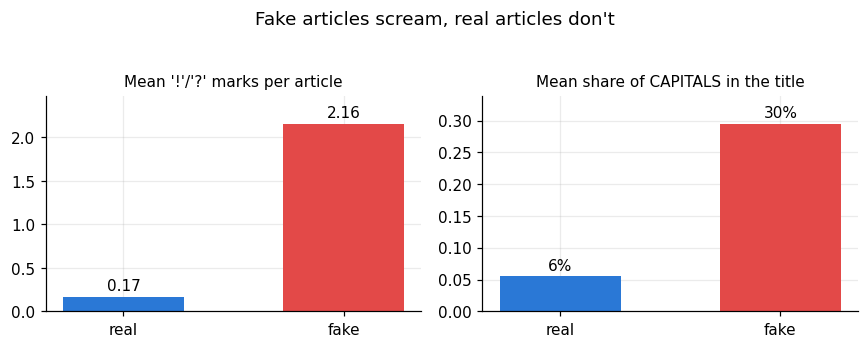

In [2]:
isot["exclamations"] = isot["full_text"].str.count(r"[!?]")
isot["caps_ratio"] = isot["title"].fillna("").apply(
    lambda t: sum(c.isupper() for c in t) / max(len(t), 1)
)

style = isot.groupby("label")[["exclamations", "caps_ratio"]].mean().loc[["real", "fake"]]

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for ax, col, title, fmt in (
    (axes[0], "exclamations", "Mean '!'/'?' marks per article", "{:.2f}"),
    (axes[1], "caps_ratio", "Mean share of CAPITALS in the title", "{:.0%}"),
):
    bars = ax.bar(style.index, style[col], color=[REAL_COLOR, FAKE_COLOR], width=0.55)
    ax.bar_label(bars, fmt=fmt, padding=2)
    ax.set_title(title, fontsize=10)
    ax.margins(y=0.15)
fig.suptitle("Fake articles scream, real articles don't", y=1.04, fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES / "style_leakage.png", bbox_inches="tight")
plt.show()

## 2. Source leakage: the `(Reuters)` watermark

Every ISOT *real* article comes from Reuters — and most keep the newswire
dateline (`WASHINGTON (Reuters) -`). A classifier only needs to spot that token.
This is not a hypothetical: the SVM's top features in the original experiments
were dominated by source markers, not content words.

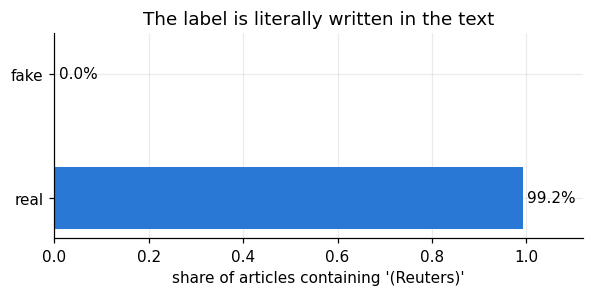

Example of a 'real' article opening:
WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, calle …


In [3]:
reuters_share = (
    isot.groupby("label")["text"]
    .apply(lambda s: s.fillna("").str.contains(r"\(Reuters\)").mean())
    .loc[["real", "fake"]]
)

fig, ax = plt.subplots(figsize=(5.5, 2.8))
bars = ax.barh(reuters_share.index, reuters_share.values,
               color=[REAL_COLOR, FAKE_COLOR], height=0.5)
ax.bar_label(bars, fmt="{:.1%}", padding=3)
ax.set_xlim(0, 1.12)
ax.set_xlabel("share of articles containing '(Reuters)'")
ax.set_title("The label is literally written in the text")
fig.tight_layout()
fig.savefig(FIGURES / "reuters_leakage.png", bbox_inches="tight")
plt.show()

print("Example of a 'real' article opening:")
print(real["text"].iloc[0][:180], "…")

## 3. Temporal blindness: a 2015–2017 snapshot

The corpus stops in early 2018. A model trained here has never seen COVID,
the 2020 election, or the war in Ukraine — every claim about them is
out-of-domain. Worse, the fake/real volumes are not even aligned in time,
so *when* an article was written correlates with its label.

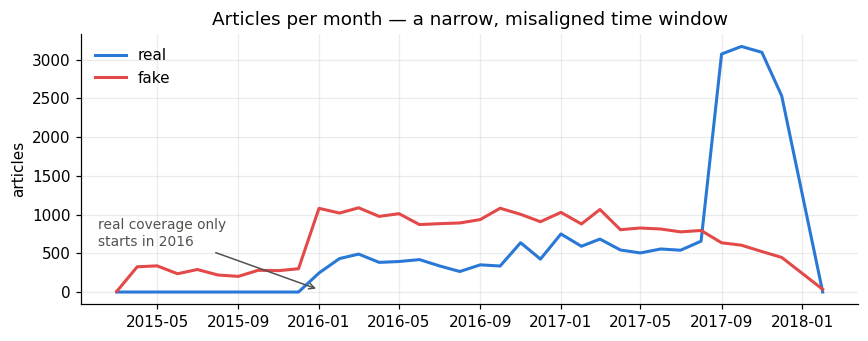

In [4]:
isot["date_parsed"] = pd.to_datetime(isot["date"], errors="coerce", format="mixed")
monthly = (
    isot.dropna(subset=["date_parsed"])
    .groupby([pd.Grouper(key="date_parsed", freq="MS"), "label"])
    .size().unstack(fill_value=0)
    .loc["2015":"2018-02"]
)

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(monthly.index, monthly["real"], color=REAL_COLOR, lw=2, label="real")
ax.plot(monthly.index, monthly["fake"], color=FAKE_COLOR, lw=2, label="fake")
ax.set_title("Articles per month — a narrow, misaligned time window")
ax.set_ylabel("articles")
ax.legend(frameon=False)
ax.annotate("real coverage only\nstarts in 2016", xy=(pd.Timestamp("2016-01-01"), 30),
            xytext=(pd.Timestamp("2015-02-01"), 600), fontsize=9, color="#52514e",
            arrowprops=dict(arrowstyle="->", color="#52514e"))
fig.tight_layout()
fig.savefig(FIGURES / "temporal_window.png", bbox_inches="tight")
plt.show()

## Consequences → design decisions

| Bias found | Countermeasure in the final system |
|---|---|
| Stylistic leakage | WELFake slice filtered on caps ratio / punctuation before fusion |
| Source leakage | multi-source fusion (ISOT + WELFake + COVID) so no single outlet defines "real" |
| Temporal blindness | COVID slice balanced and oversampled **in the training split only**; out-of-domain adversarial benchmark kept as a permanent regression test |
| Inflated metrics | deduplication and train/test split **before** any oversampling; one shared test set for every model |

With the clean protocol the ensemble scores **94.6% in-domain** but only
**76.2% on 101 out-of-domain adversarial scenarios** (see
`benchmarks/adversarial_results.json`). That gap *is* the honest headline of
this project: it is why the demo ships a reference-corpus heuristic and a
human-review flag instead of claiming to be a truth oracle.